# Baseline NBSVM — TF-IDF + Naive Bayes + Regresión Logística

In [ ]:
# TODO = AGREGAR SIN HASHTAGS
!git clone https://github.com/camistrika/BETO_HUMOR.git
%cd BETO_HUMOR
!pip install -e . -q

In [ ]:
!pip install -q torchao --upgrade
!pip install -q transformers peft datasets scikit-learn pyyaml

In [1]:
import os
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from IPython.display import display

from betohumor.config import DataConfig, NbsvmConfig
from betohumor.utils import set_seed
from betohumor.dataset import load_and_split
from betohumor.metrics import (
    nb_log_ratio,
    get_classification_report_df,
    get_confusion_matrix,
    get_top_words_nbsvm,
)
from betohumor.models.nbsvm import build_nbsvm_vectorizer, build_nbsvm_classifier
from betohumor.plots import plot_confusion_matrix, plot_top_words

## 1. Datos

In [7]:
data_config  = DataConfig(data_path = "../data/raw/haha_2019_train.csv")
nbsvm_config = NbsvmConfig()
set_seed(data_config.seed)

df_train, df_val, df_test = load_and_split(data_config)

text_col  = data_config.text_col
label_col = data_config.label_col

X_train = df_train[text_col].tolist()
y_train = np.array(df_train[label_col].tolist())
X_val   = df_val[text_col].tolist()
y_val   = np.array(df_val[label_col].tolist())
X_test  = df_test[text_col].tolist()
y_test  = np.array(df_test[label_col].tolist())

Train: 19197 | Val: 2397 | Test: 2400


## 2. TF-IDF + log-ratio de Naive Bayes (NBSVM)

In [8]:
vectorizer = build_nbsvm_vectorizer(nbsvm_config)
x_train = vectorizer.fit_transform(X_train)
x_val   = vectorizer.transform(X_val)
x_test  = vectorizer.transform(X_test)

r = nb_log_ratio(x_train, 1, y_train) / nb_log_ratio(x_train, 0, y_train)
r = np.log(r)

## 3. Entrenamiento de la Regresión Logística

In [9]:
clf = build_nbsvm_classifier(nbsvm_config, seed=data_config.seed)
clf.fit(x_train.multiply(r), y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",4.0
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## 4. Métricas en validación

In [10]:
preds_val = clf.predict(x_val.multiply(r))

print(f"Accuracy: {accuracy_score(y_val, preds_val):.4f} | Macro F1: {f1_score(y_val, preds_val, average='macro'):.4f}")

df_report = get_classification_report_df(y_val, preds_val)
display(df_report)

Accuracy: 0.7839 | Macro F1: 0.7633


,precision,recall,f1-score
No humor,0.793,0.878,0.833
Humor,0.765,0.634,0.693
macro avg,0.779,0.756,0.763


## 5. Matriz de confusión

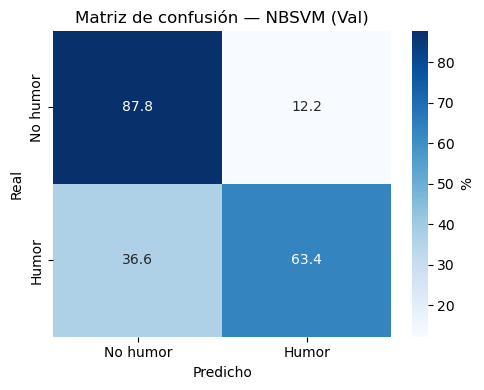

In [11]:
cm = get_confusion_matrix(y_val, preds_val, normalize='true')
fig = plot_confusion_matrix(cm, title='Matriz de confusión — NBSVM (Val)')

# Guardado manual, si lo querés conservar:
# fig.savefig('../results/figures/confusion_matrix_baseline.png', dpi=150)

## 6. Top palabras por clase

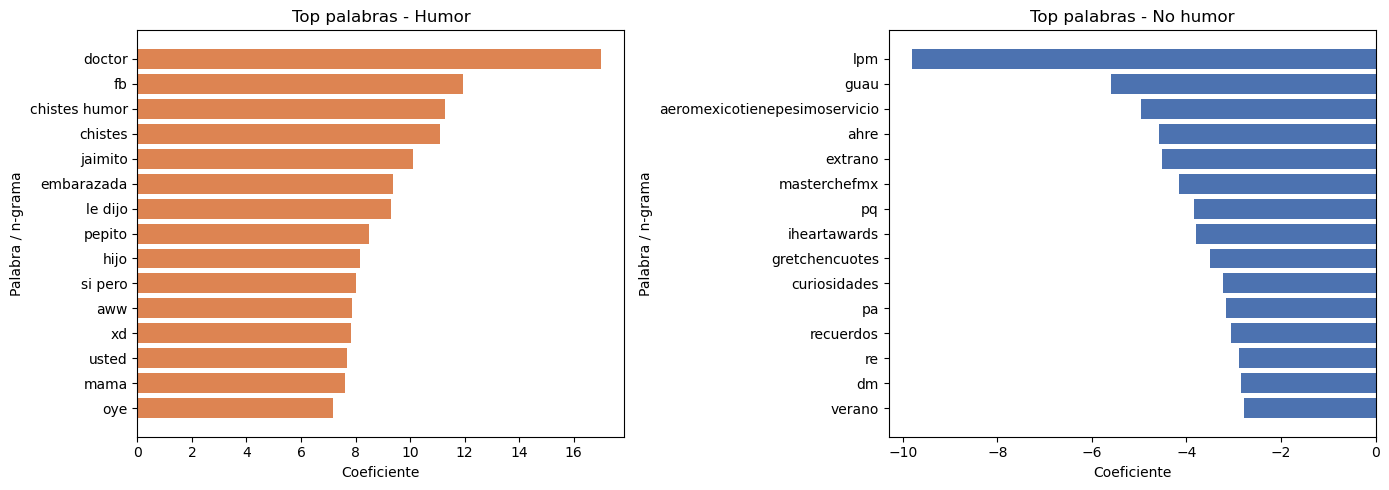

In [12]:
top_humor, top_no_humor = get_top_words_nbsvm(vectorizer, clf, r, top_n=15)
fig = plot_top_words(top_humor, top_no_humor)

# Guardado manual, si lo querés conservar:
# fig.savefig('../results/figures/top_words_baseline.png', dpi=150)

## 7. (Opcional) Métricas finales en test
Tocar test recién cuando el modelo esté definitivo.

In [13]:
preds_test = clf.predict(x_test.multiply(r))
print(f"Accuracy: {accuracy_score(y_test, preds_test):.4f} | Macro F1: {f1_score(y_test, preds_test, average='macro'):.4f}")
display(get_classification_report_df(y_test, preds_test))

Accuracy: 0.7821 | Macro F1: 0.7580


,precision,recall,f1-score
No humor,0.783,0.893,0.834
Humor,0.781,0.605,0.682
macro avg,0.782,0.749,0.758


## 8. Guardar datos

In [16]:
os.makedirs("../results/nbsvm", exist_ok = True)
get_classification_report_df(y_test, preds_test).to_csv("../results/nbsvm/metrics.csv")